# Unsupervised learning exercise: Clustering load profiles of different users

In unsupervised learning, a common task is cluster analysis, where the goal is to uncover hidden patterns or natural groupings within the data. Unlike supervised learning, there is no predefined “correct” answer, so you must interpret the clusters and evaluate whether the results are meaningful.

**Objective:** In this exercise, you will work with load profile data from multiple users in Belgium. Although the original dataset includes information about installed DERs (e.g., no DERs, PV, PV + EV, EV + heat pump), these labels will not be used during training. Instead, the aim is to engineer relevant features from the load profiles and explore different ways to cluster users based solely on their consumption behavior.

**Context:** This unsupervised learning problem invites you to experiment with various clustering algorithms and evaluation techniques. You are encouraged to:

* Extract and compare features from the raw profiles (e.g., daily patterns, variability, peak timing),

* Try different clustering approaches,

* Analyze how well the resulting groups reflect meaningful differences in user behavior.

There is no single “correct” outcome. Your task is to interpret the clusters, assess their validity, and discuss what they reveal about distinct consumption patterns across users.

### Before we start:

* The file **sm_hourly_profiles_belgium.csv** contains the input dataset for this exercise.

## **1. Import libraries and data**

In [1]:
# Import libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Import dataset
df_raw = pd.read_csv('Data/sm_hourly_profiles_belgium.csv')
df_raw

,SM_ID,Label,Start_Date,SM_kWh
0,SM_0001,EV_PV,2024-01-01 00:00:00+00:00,0.293
1,SM_0001,EV_PV,2024-01-01 01:00:00+00:00,0.245
2,SM_0001,EV_PV,2024-01-01 02:00:00+00:00,0.285
3,SM_0001,EV_PV,2024-01-01 03:00:00+00:00,0.246
4,SM_0001,EV_PV,2024-01-01 04:00:00+00:00,0.257
...,...,...,...,...
10539595,SM_1200,EV_PV,2024-12-31 19:00:00+00:00,0.733
10539596,SM_1200,EV_PV,2024-12-31 20:00:00+00:00,0.771
10539597,SM_1200,EV_PV,2024-12-31 21:00:00+00:00,0.623
10539598,SM_1200,EV_PV,2024-12-31 22:00:00+00:00,0.789


## **2. Understanding the data**

It is necessary to visualize and understand the data we are going to work with, as well as to know its characteristics.

1. How much data is there? How many attributes are there in the data?  
2. What do they mean?
3. Is there any missing data?
4. Statistical summary of the input data set.

In [2]:
# Dimension of input data (rows x columns)
df_raw.shape

(10539600, 4)

In [3]:
# Let's see what the data looks like
df_raw.head()

,SM_ID,Label,Start_Date,SM_kWh
0,SM_0001,EV_PV,2024-01-01 00:00:00+00:00,0.293
1,SM_0001,EV_PV,2024-01-01 01:00:00+00:00,0.245
2,SM_0001,EV_PV,2024-01-01 02:00:00+00:00,0.285
3,SM_0001,EV_PV,2024-01-01 03:00:00+00:00,0.246
4,SM_0001,EV_PV,2024-01-01 04:00:00+00:00,0.257


In [4]:
df_raw.dtypes

SM_ID          object
Label          object
Start_Date     object
SM_kWh        float64
dtype: object

**2. What do they mean?** 

* **[SM_ID]**: random SM ID
* **[Label]**: label based on DERs
* **[Start_Date]**: datetime with hourly granularity
* **[SM_kWh]**: energy or power consumed in each period [kWh or kW since timestamp is hourly].

**3. Is any data missing?** A check is made to see if any data is missing, and then empty cells are counted.
In this case, no data is missing in the input data set (there are no *Nan* values).

In [5]:
df_raw.isna().sum()

SM_ID         0
Label         0
Start_Date    0
SM_kWh        0
dtype: int64

**4. Summary statistics of the input data set:** Descriptive statistics collects and analyzes the input data set with the objective of describing the characteristics and behaviors of this set through the following summary measures: total number of observations (count), mean (mean), standard deviation (std), minimum value (min), maximum value (max) and the values of the different quartiles (25%, 50%, 75%).

In [6]:
# Evaluate the nature of the data with descriptive statistics.
df_raw.describe()

,SM_kWh
count,1.053960e+07
mean,3.746398e-01
std,1.201039e+00
min,-9.564000e+00
25%,6.500000e-02
50%,1.840000e-01
75%,4.420000e-01
max,2.285000e+01


In [7]:
# you can extend the data analysis if you want




## **3. Visualize the data**

A visual way to understand the input data. 
1. Histogram
2. Density curve
3. Boxplots

**1. Histogram**

Graphical representation of each of the attributes in the form of bars, where the surface of the bar is proportional to the frequency of the values represented.

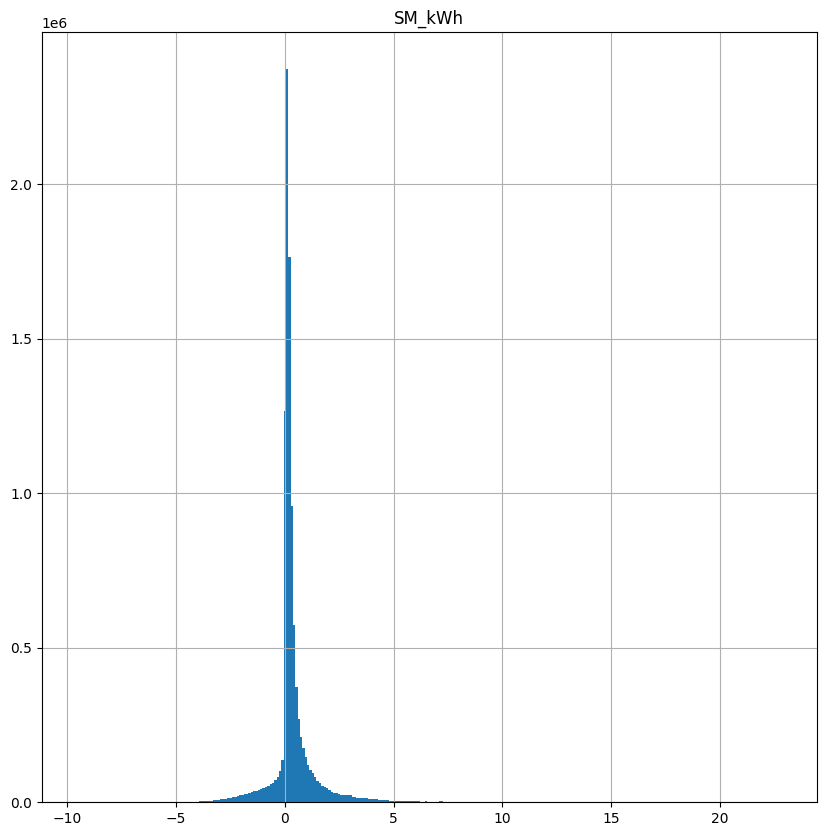

In [7]:
histogram = df_raw.hist(xlabelsize=10, ylabelsize=10, bins=300, figsize=(10, 10))

**2. Density graph**

Visualize the distribution of the data. It is a variable of the histogram, but eliminates noise, so they are better for determining the distribution shape of an attribute. Density plot spikes help show where values are most concentrated. 

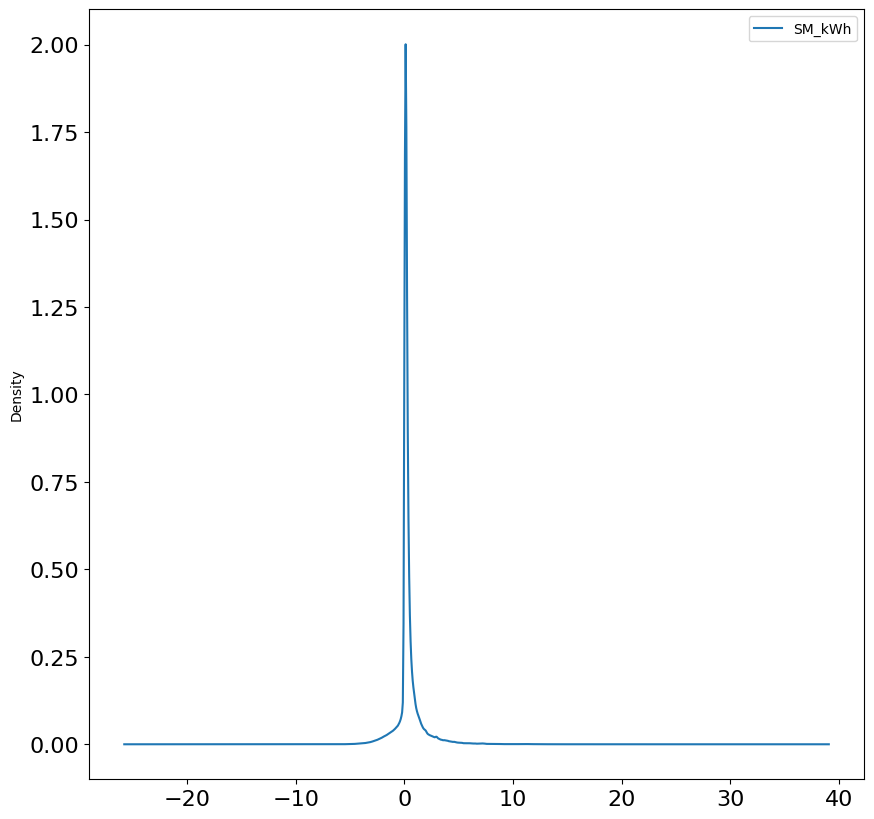

In [8]:
density = df_raw.plot(kind='kde', legend=True, layout=(1, 1), figsize=(10, 10), fontsize=16, stacked=True) 

**3. Boxplots** 

The boxplot allows us to identify outliers and compare distributions. In addition, we know how 50% of the values are distributed (inside the box). 

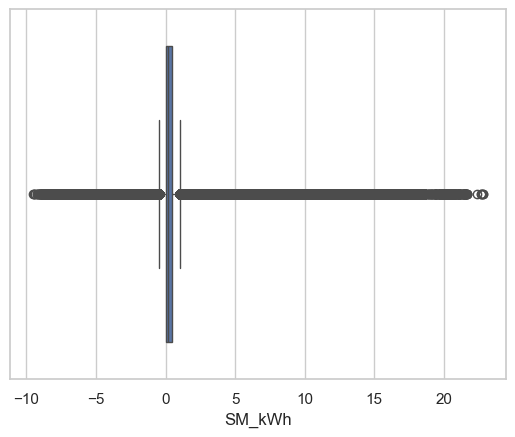

In [10]:
sns.set(style="whitegrid")
ax = sns.boxplot(x=df_raw["SM_kWh"])

In [17]:
# Additional visualization if you want. For example, you could do plots by 'Label'

## Let's continue without the Label column

In [8]:
df_sm = df_raw[['SM_ID', 'Start_Date', 'SM_kWh']]
df_sm

,SM_ID,Start_Date,SM_kWh
0,SM_0001,2024-01-01 00:00:00+00:00,0.293
1,SM_0001,2024-01-01 01:00:00+00:00,0.245
2,SM_0001,2024-01-01 02:00:00+00:00,0.285
3,SM_0001,2024-01-01 03:00:00+00:00,0.246
4,SM_0001,2024-01-01 04:00:00+00:00,0.257
...,...,...,...
10539595,SM_1200,2024-12-31 19:00:00+00:00,0.733
10539596,SM_1200,2024-12-31 20:00:00+00:00,0.771
10539597,SM_1200,2024-12-31 21:00:00+00:00,0.623
10539598,SM_1200,2024-12-31 22:00:00+00:00,0.789


## *4. Data Preparation: From time-series to feature dataset*

The original dataset contains time-series load measurements for multiple smart meters (SMs), identified by the `SM_ID` column. Each user has many hourly readings across the year.  
However, for clustering we need a **single feature vector per user**, not raw time-series data.

#### Steps to prepare the data

1. **Start from the raw time series**  
   Each row represents a timestamped load value for a given `SM_ID`.

2. **Group the data by smart meter (`SM_ID`)**  
   This allows us to summarize each user’s consumption behavior.

3. **Engineer features for each SM**  
   Examples of possible features include:
   - statistical features (mean, median, standard deviation, peak load)
   - temporal characteristics (typical peak hour, load factor, weekday/weekend ratio)
   - shape-based features (average daily profile, seasonal variability)
   - optional: use the **tsfeatures** library (https://github.com/Nixtla/tsfeatures) or the **IFEEL-Interpretable Feature Extraction of Electricity Loads** library (https://maomaohu.net/software/ifeel/)

4. **Create a new dataset**  
   After feature extraction, the resulting table should have:
   - **one row per SM**
   - **one column per feature**
   - no timestamps

   Example structure:

   | ID   | mean_load | peak_load | std_dev | peak_hour | weekend_ratio | … |
   |------|-----------|-----------|---------|------------|----------------|---|
   | SM_0001 | 0.87      | 3.12      | 0.54    | 19:00      | 1.12           | … |
   | SM_0002 | 0.45      | 1.98      | 0.31    | 14:00      | 0.85           | … |

5. **Scale and clean the features**
   - handle missing values  
   - apply normalization or standardization before clustering

---

Once prepared, this feature-based dataset can be used as the input to clustering algorithms to reveal similarities and differences in user load profiles.


# Option A: minimal FE

In [15]:
df_features = df_sm.groupby('SM_ID')['SM_kWh'].agg(['mean', 'median', 'max', 'min', 'std', 'sum']).reset_index()
df_features

,SM_ID,mean,median,max,min,std,sum
0,SM_0001,0.153860,0.269,6.691,-3.728,1.049237,1351.350
1,SM_0002,-0.011167,0.158,4.212,-2.078,0.658385,-98.083
2,SM_0003,0.173018,0.004,10.233,-3.900,1.629995,1519.619
3,SM_0004,-0.119556,0.148,3.739,-4.154,0.927797,-1050.058
4,SM_0005,-0.171893,0.151,2.306,-3.497,0.797882,-1509.738
...,...,...,...,...,...,...,...
1195,SM_1196,0.033122,0.047,2.109,-1.555,0.346136,290.910
1196,SM_1197,-0.320193,0.208,6.121,-4.797,1.532919,-2812.252
1197,SM_1198,0.030139,0.151,7.849,-5.946,1.942942,264.713
1198,SM_1199,0.043959,0.135,1.844,-1.741,0.394752,386.090


In [28]:
df_labels = df_raw[['SM_ID', 'Label']].drop_duplicates()
df_labels = df_labels.sort_values(by='SM_ID').reset_index(drop=True)
df_labels

,SM_ID,Label
0,SM_0001,EV_PV
1,SM_0002,PV
2,SM_0003,EV_PV
3,SM_0004,PV
4,SM_0005,PV
...,...,...
1195,SM_1196,PV
1196,SM_1197,EV_PV
1197,SM_1198,EV_PV
1198,SM_1199,PV


### Scale -> Elbow Method -> Clustering -> PCA -> Plot

In [ ]:
# scale data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_features.drop('SM_ID', axis=1))
X_scaled

array([[-0.42309099,  0.07938767,  0.32268981, -1.02461853,  0.24629881,
        -0.42309099],
       [-0.73933995, -0.31049648, -0.39833704, -0.19513621, -0.40845733,
        -0.73933995],
       [-0.38637671, -0.85141685,  1.35289437, -1.11108577,  1.21918667,
        -0.38637671],
       ...,
       [-0.6601822 , -0.33508377,  0.65949864, -2.13964385,  1.74343593,
        -0.6601822 ],
       [-0.63369919, -0.39128329, -1.0870791 , -0.02572073, -0.85009613,
        -0.63369919],
       [ 0.15126656, -0.25780944, -0.02109951, -0.28411704,  0.57046059,
         0.15126656]], shape=(1200, 6))

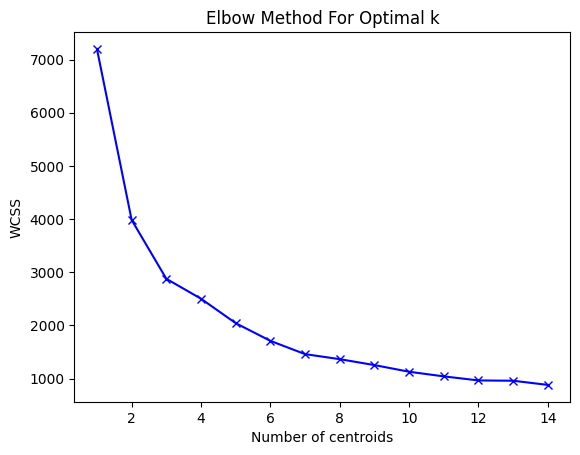

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans


wcss = []
K = range(1,15)

for k in K:
    km = KMeans(n_clusters=k)
    km = km.fit(X_scaled)
    wcss.append(km.inertia_)
plt.plot(K, wcss, 'bx-')
plt.xlabel('Number of centroids')
plt.ylabel('WCSS')
plt.title('Elbow Method For Optimal k')
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=0).fit(X_scaled)
y_kmeans = kmeans.predict(X_scaled)

Text(0, 0.5, 'Min kWh')

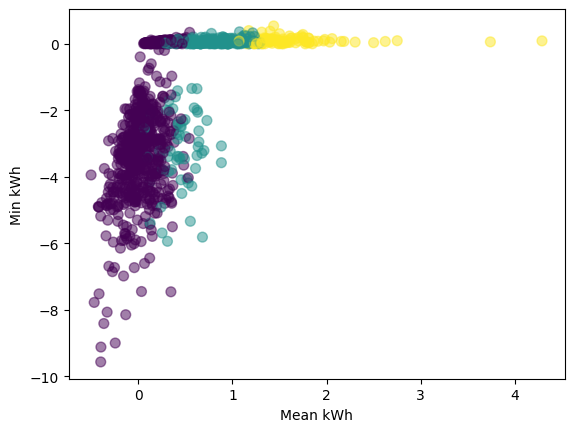

In [ ]:
plt.scatter(df_features['mean'], df_features['min'], c=y_kmeans, s=50, alpha=0.5,cmap='viridis')
centers = kmeans.cluster_centers_
plt.xlabel('Mean kWh')
plt.ylabel('Min kWh')

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_features.drop('SM_ID', axis=1))  # Scaling the data


pca = PCA(n_components=2)
results_pca = pca.fit_transform(scaled_data)
print(results_pca)

[[-0.42872624 -1.06208312]
 [-1.20935264  0.01835239]
 [-0.05366436 -2.22931147]
 ...
 [-0.45147579 -2.92159471]
 [-1.51951334  0.68690171]
 [ 0.16673769 -0.50034678]]


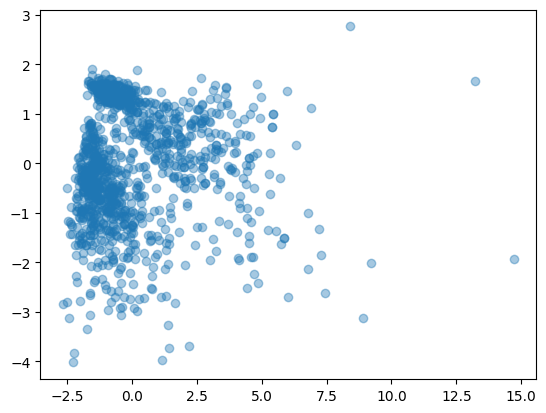

In [ ]:
plt.scatter(results_pca[:, 0], results_pca[:, 1],alpha=0.4)
plt.show()

Text(0, 0.5, 'PC 2')

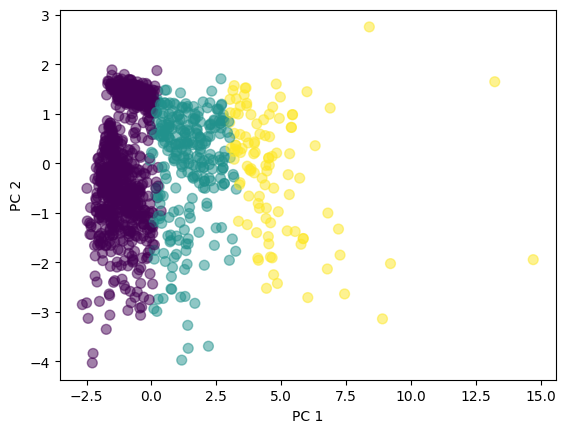

In [ ]:
plt.scatter(results_pca[:, 0], results_pca[:, 1], c=y_kmeans, s=50, alpha=0.5,cmap='viridis')
centers = kmeans.cluster_centers_
plt.xlabel('PC 1')
plt.ylabel('PC 2')

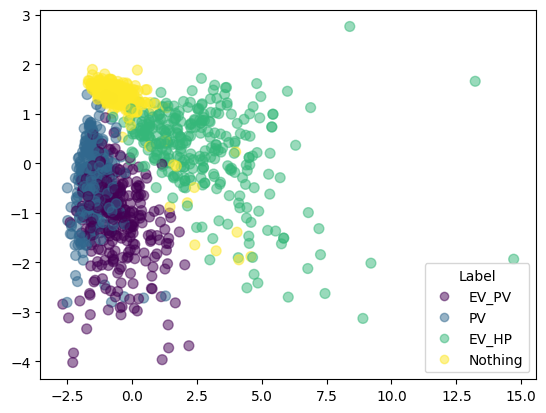

In [40]:
labels_encoded, labels = pd.factorize(df_labels['Label'])

scatter = plt.scatter(
    results_pca[:,0], results_pca[:,1],
    c=labels_encoded, cmap='viridis', s=50, alpha=0.5
)

# Automatically create legend elements
handles, _ = scatter.legend_elements()

plt.legend(handles, labels, title="Label")


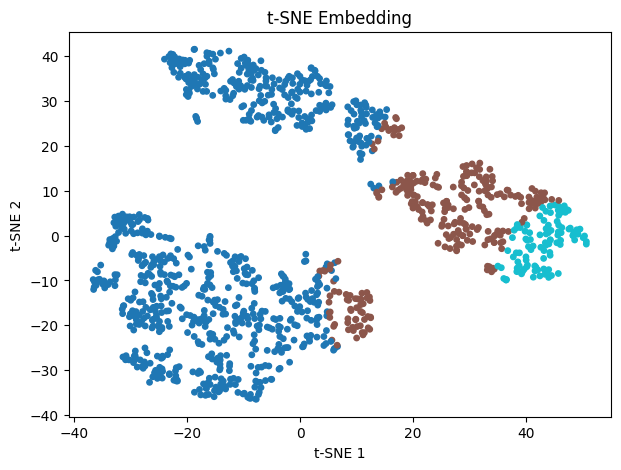

In [36]:
from sklearn.manifold import TSNE

# t-SNE (components mean dimensions)
tsne = TSNE(n_components=2, perplexity=30, learning_rate='auto', init='pca', random_state=42)
X_embedded = tsne.fit_transform(scaled_data)

# Plot
plt.figure(figsize=(7,5))
plt.scatter(X_embedded[:, 0], X_embedded[:, 1], c=y_kmeans, s=15, cmap="tab10")
plt.title("t-SNE Embedding")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.show()

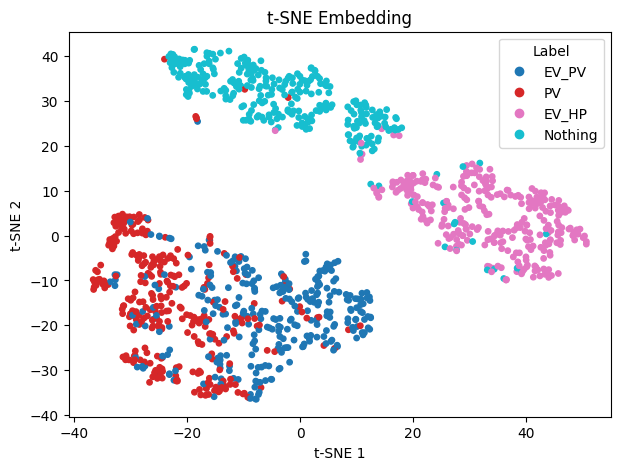

In [44]:
# factorize labels
labels_encoded, unique_labels = pd.factorize(df_labels['Label'])

# t-SNE
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate='auto',
    init='pca',
    random_state=42
)
X_embedded = tsne.fit_transform(scaled_data)

# Plot
plt.figure(figsize=(7, 5))
sc = plt.scatter(
    X_embedded[:, 0],
    X_embedded[:, 1],
    c=labels_encoded,
    s=15,
    cmap="tab10"
)
plt.title("t-SNE Embedding")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")

# Legend from scatter
handles, _ = sc.legend_elements()
plt.legend(handles, unique_labels, title="Label")

plt.show()

# Option B: domain-oriented FE

In [58]:
df_basic_features = df_sm.groupby('SM_ID')['SM_kWh'].agg(['mean', 'median', 'max', 'min', 'std', 'sum']).reset_index()
df_basic_features

,SM_ID,mean,median,max,min,std,sum
0,SM_0001,0.153860,0.269,6.691,-3.728,1.049237,1351.350
1,SM_0002,-0.011167,0.158,4.212,-2.078,0.658385,-98.083
2,SM_0003,0.173018,0.004,10.233,-3.900,1.629995,1519.619
3,SM_0004,-0.119556,0.148,3.739,-4.154,0.927797,-1050.058
4,SM_0005,-0.171893,0.151,2.306,-3.497,0.797882,-1509.738
...,...,...,...,...,...,...,...
1195,SM_1196,0.033122,0.047,2.109,-1.555,0.346136,290.910
1196,SM_1197,-0.320193,0.208,6.121,-4.797,1.532919,-2812.252
1197,SM_1198,0.030139,0.151,7.849,-5.946,1.942942,264.713
1198,SM_1199,0.043959,0.135,1.844,-1.741,0.394752,386.090


In [54]:
def find_peak_hour(df):
    df = df.copy()
    df['Start_Date'] = pd.to_datetime(df['Start_Date'])
    df['date'] = df['Start_Date'].dt.date
    df['hour'] = df['Start_Date'].dt.hour
    peak_hour = df.loc[df.groupby('date')['SM_kWh'].idxmax()]['hour'].value_counts().idxmax()
    return peak_hour

In [55]:
def get_we_wd_ratio(df):
    df = df.copy()
    df['Start_Date'] = pd.to_datetime(df['Start_Date'])
    df['day_of_week'] = df['Start_Date'].dt.dayofweek
    df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)
    weekend_consumption = df[df['is_weekend'] == 1]['SM_kWh'].mean()
    weekday_consumption = df[df['is_weekend'] == 0]['SM_kWh'].mean()
    ratio = weekend_consumption / weekday_consumption if weekday_consumption != 0 else np.nan
    return ratio

In [56]:
def get_day_night_ratio(df):
    df = df.copy()
    df['Start_Date'] = pd.to_datetime(df['Start_Date'])
    df['hour'] = df['Start_Date'].dt.hour
    day_consumption = df[(df['hour'] >= 7) & (df['hour'] < 19)]['SM_kWh'].mean()
    night_consumption = df[(df['hour'] < 7) | (df['hour'] >= 19)]['SM_kWh'].mean()
    ratio = day_consumption / night_consumption if night_consumption != 0 else np.nan
    return ratio

In [99]:
def get_negative_consumption_ratio(df):
    df = df.copy()
    negative_count = (df['SM_kWh'] < 0).sum()
    total_count = len(df)
    ratio = negative_count / total_count if total_count != 0 else np.nan
    return ratio

In [100]:
di_features = {}

for sm in df_basic_features['SM_ID'].unique():
    customer_features = {}
    df_customer = df_sm[df_sm['SM_ID'] == sm]
    peak_hour = find_peak_hour(df_customer)
    customer_features['peak_hour'] = peak_hour
    we_wd_ratio = get_we_wd_ratio(df_customer)
    customer_features['we_wd_ratio'] = we_wd_ratio
    day_night_ratio = get_day_night_ratio(df_customer)
    customer_features['day_night_ratio'] = day_night_ratio
    negative_consumption_ratio = get_negative_consumption_ratio(df_customer)
    customer_features['negative_consumption_ratio'] = negative_consumption_ratio
    di_features[sm] = customer_features
    pct = (len(di_features) / df_basic_features['SM_ID'].nunique()) * 100
    print(f"\rProgress: {pct:.2f}%", end='')

df_additional_features = pd.DataFrame.from_dict(di_features, orient='index').reset_index()
df_additional_features.rename(columns={'index': 'SM_ID'}, inplace=True)
df_additional_features

df_features = pd.merge(df_basic_features, df_additional_features, on='SM_ID')
df_features['load_factor'] = df_features['mean'] / (df_features['max'] + 1e-6)
df_features

Progress: 100.00%

,SM_ID,mean,median,max,min,std,sum,peak_hour,we_wd_ratio,day_night_ratio,negative_consumption_ratio,load_factor
0,SM_0001,0.153860,0.269,6.691,-3.728,1.049237,1351.350,21,0.269309,-0.197461,0.235227,0.022995
1,SM_0002,-0.011167,0.158,4.212,-2.078,0.658385,-98.083,18,-0.495746,-1.090584,0.282591,-0.002651
2,SM_0003,0.173018,0.004,10.233,-3.900,1.629995,1519.619,7,5.486193,-0.392187,0.219629,0.016908
3,SM_0004,-0.119556,0.148,3.739,-4.154,0.927797,-1050.058,19,1.353447,-1.810951,0.323580,-0.031975
4,SM_0005,-0.171893,0.151,2.306,-3.497,0.797882,-1509.738,19,1.143509,-2.514535,0.317887,-0.074542
...,...,...,...,...,...,...,...,...,...,...,...,...
1195,SM_1196,0.033122,0.047,2.109,-1.555,0.346136,290.910,17,1.457489,-0.355153,0.133440,0.015705
1196,SM_1197,-0.320193,0.208,6.121,-4.797,1.532919,-2812.252,20,1.051488,-2.281928,0.374473,-0.052311
1197,SM_1198,0.030139,0.151,7.849,-5.946,1.942942,264.713,0,0.230457,-0.933215,0.344529,0.003840
1198,SM_1199,0.043959,0.135,1.844,-1.741,0.394752,386.090,17,0.722760,-0.545183,0.243653,0.023839


In [101]:
df_features.drop(columns=['max', 'sum'], inplace=True)

In [102]:
df_labels = df_raw[['SM_ID', 'Label']].drop_duplicates()
df_labels = df_labels.sort_values(by='SM_ID').reset_index(drop=True)
df_labels

,SM_ID,Label
0,SM_0001,EV_PV
1,SM_0002,PV
2,SM_0003,EV_PV
3,SM_0004,PV
4,SM_0005,PV
...,...,...
1195,SM_1196,PV
1196,SM_1197,EV_PV
1197,SM_1198,EV_PV
1198,SM_1199,PV


### Scale -> Elbow Method -> Clustering -> PCA -> Plot

In [103]:
# scale data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_features.drop('SM_ID', axis=1))
X_scaled

array([[-0.42309099,  0.07938767, -1.02461853, ..., -0.0418943 ,
         0.59531151, -0.43570366],
       [-0.73933995, -0.31049648, -0.19513621, ..., -0.48069831,
         0.89333352, -0.77775595],
       [-0.38637671, -0.85141685, -1.11108577, ..., -0.13756585,
         0.49716483, -0.51688973],
       ...,
       [-0.6601822 , -0.33508377, -2.13964385, ..., -0.4033809 ,
         1.28305461, -0.69118099],
       [-0.63369919, -0.39128329, -0.02572073, ..., -0.2127349 ,
         0.64832504, -0.4244499 ],
       [ 0.15126656, -0.25780944, -0.28411704, ...,  0.28588889,
         0.50504522,  0.35570831]], shape=(1200, 9))

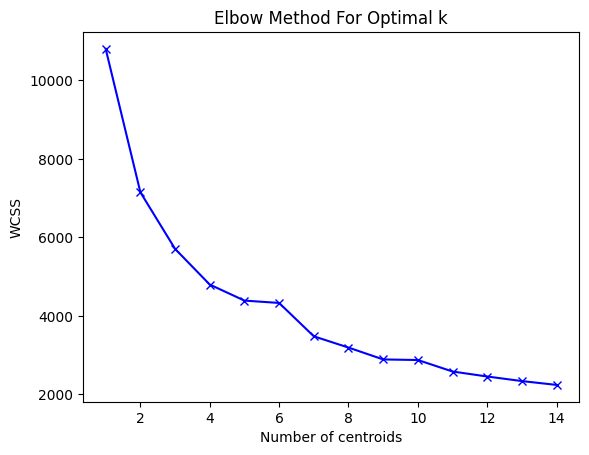

In [104]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans


wcss = []
K = range(1,15)

for k in K:
    km = KMeans(n_clusters=k)
    km = km.fit(X_scaled)
    wcss.append(km.inertia_)
plt.plot(K, wcss, 'bx-')
plt.xlabel('Number of centroids')
plt.ylabel('WCSS')
plt.title('Elbow Method For Optimal k')
plt.show()

In [105]:
kmeans = KMeans(n_clusters=4, random_state=0).fit(X_scaled)
y_kmeans = kmeans.predict(X_scaled)

Text(0, 0.5, 'Min kWh')

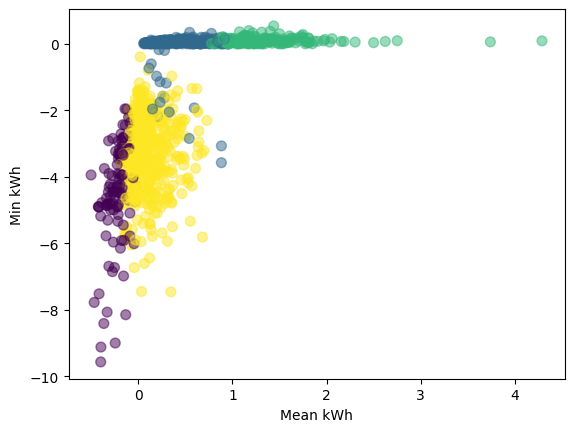

In [106]:
plt.scatter(df_features['mean'], df_features['min'], c=y_kmeans, s=50, alpha=0.5,cmap='viridis')
centers = kmeans.cluster_centers_
plt.xlabel('Mean kWh')
plt.ylabel('Min kWh')

In [107]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_features.drop('SM_ID', axis=1))  # Scaling the data


pca = PCA(n_components=2)
results_pca = pca.fit_transform(scaled_data)
print(results_pca)

[[-1.05217596  0.36704944]
 [-1.47507802 -0.29080012]
 [-1.22706512  1.12606924]
 ...
 [-2.026182    2.28987483]
 [-1.05937488 -0.76223846]
 [-0.0462877   0.36000028]]


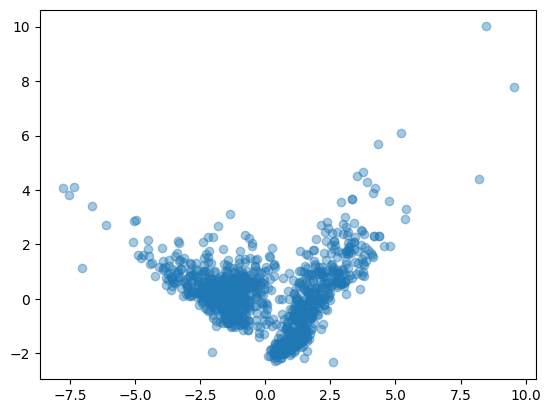

In [108]:
plt.scatter(results_pca[:, 0], results_pca[:, 1],alpha=0.4)
plt.show()

Text(0, 0.5, 'PC 2')

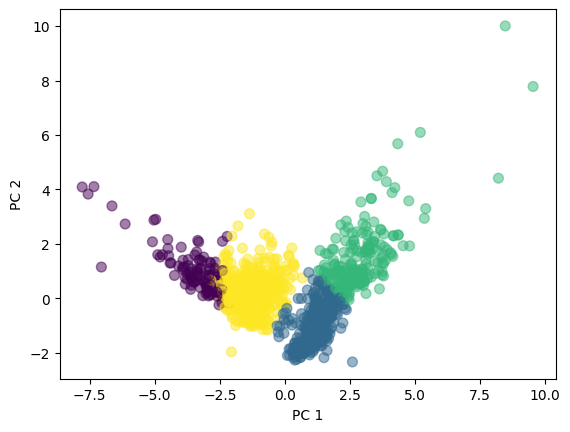

In [109]:
plt.scatter(results_pca[:, 0], results_pca[:, 1], c=y_kmeans, s=50, alpha=0.5,cmap='viridis')
centers = kmeans.cluster_centers_
plt.xlabel('PC 1')
plt.ylabel('PC 2')

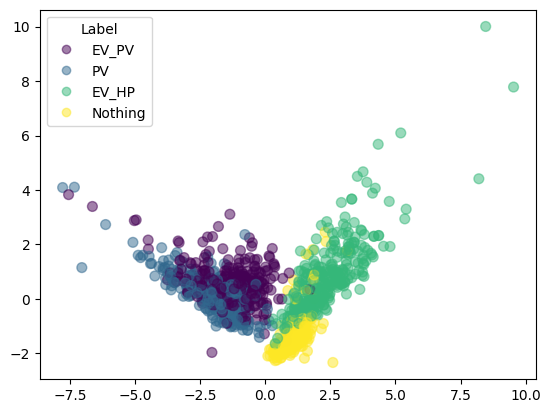

In [110]:
labels_encoded, labels = pd.factorize(df_labels['Label'])

scatter = plt.scatter(
    results_pca[:,0], results_pca[:,1],
    c=labels_encoded, cmap='viridis', s=50, alpha=0.5
)

# Automatically create legend elements
handles, _ = scatter.legend_elements()

plt.legend(handles, labels, title="Label")


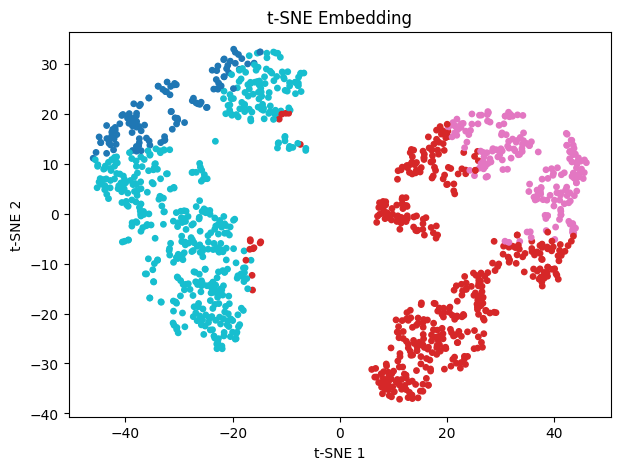

In [111]:
from sklearn.manifold import TSNE

# t-SNE (components mean dimensions)
tsne = TSNE(n_components=2, perplexity=30, learning_rate='auto', init='pca', random_state=42)
X_embedded = tsne.fit_transform(scaled_data)

# Plot
plt.figure(figsize=(7,5))
plt.scatter(X_embedded[:, 0], X_embedded[:, 1], c=y_kmeans, s=15, cmap="tab10")
plt.title("t-SNE Embedding")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.show()

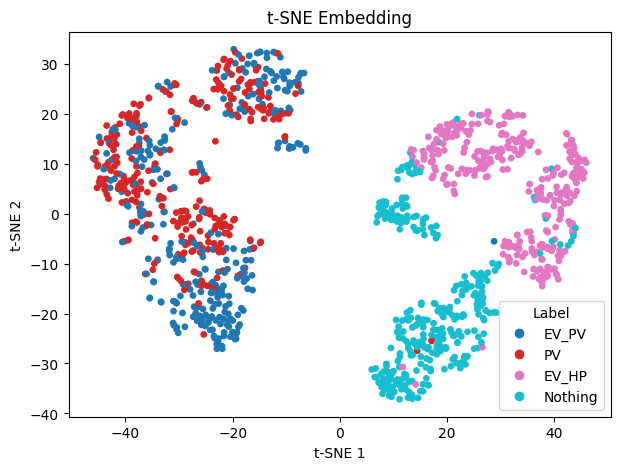

In [112]:
# factorize labels
labels_encoded, unique_labels = pd.factorize(df_labels['Label'])

# t-SNE
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate='auto',
    init='pca',
    random_state=42
)
X_embedded = tsne.fit_transform(scaled_data)

# Plot
plt.figure(figsize=(7, 5))
sc = plt.scatter(
    X_embedded[:, 0],
    X_embedded[:, 1],
    c=labels_encoded,
    s=15,
    cmap="tab10"
)
plt.title("t-SNE Embedding")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")

# Legend from scatter
handles, _ = sc.legend_elements()
plt.legend(handles, unique_labels, title="Label")

plt.show()

## 5. Unsupervised Learning Model Building: Data Clustering

## 6. Validating results with Dimensionality Reduction (PCA) or t-SNE

In [20]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_features.drop('SM_ID', axis=1))  # Scaling the data


pca = PCA(n_components=2)
results_pca = pca.fit_transform(scaled_data)
print(results_pca)

[[-0.42872624 -1.06208312]
 [-1.20935264  0.01835239]
 [-0.05366436 -2.22931147]
 ...
 [-0.45147579 -2.92159471]
 [-1.51951334  0.68690171]
 [ 0.16673769 -0.50034678]]


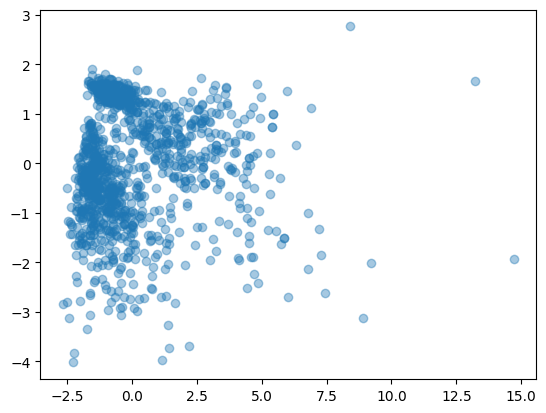

In [21]:
plt.scatter(results_pca[:, 0], results_pca[:, 1],alpha=0.4)
plt.show()

Text(0, 0.5, 'PC 2')

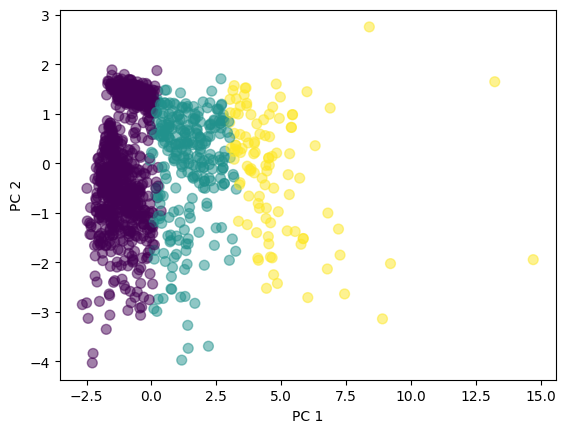

In [22]:
plt.scatter(results_pca[:, 0], results_pca[:, 1], c=y_kmeans, s=50, alpha=0.5,cmap='viridis')
centers = kmeans.cluster_centers_
plt.xlabel('PC 1')
plt.ylabel('PC 2')

Text(0, 0.5, 'PC 2')

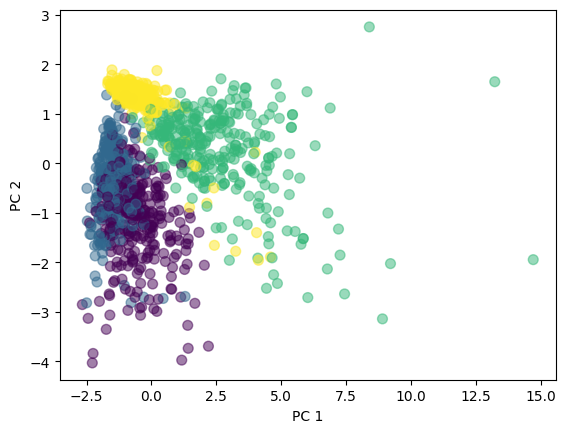

In [32]:
c_labels = df_labels['Label'].values
c_labels_encoded = pd.factorize(c_labels)[0]
c_labels_encoded
plt.scatter(results_pca[:, 0], results_pca[:, 1], c=c_labels_encoded, s=50, alpha=0.5,cmap='viridis')
plt.xlabel('PC 1')
plt.ylabel('PC 2')